## Gerrychain

In [9]:
import matplotlib.pyplot as plt
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial

In [10]:
id_graph = Graph.from_file('./ID/ID.shp')


/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/graph/graph.py:457: UserWarning: NA values found in column G18GOVDJOR!
  warnings.warn("NA values found in column {}!".format(column))
/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/graph/graph.py:457: UserWarning: NA values found in column G18GOVRLIT!
  warnings.warn("NA values found in column {}!".format(column))


  0%|          | 0/5000 [00:00<?, ?it/s]/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/updaters/tally.py:48: UserWarning: ignoring nan encountered at node '921' for attribute 'Democratic'
  warnings.warn(
/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/updaters/tally.py:48: UserWarning: ignoring nan encountered at node '923' for attribute 'Democratic'
  warnings.warn(
/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/updaters/tally.py:48: UserWarning: ignoring nan encountered at node '921' for attribute 'Republican'
  warnings.warn(
/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/gerrychain/updaters/tally.py:48: UserWarning: ignoring nan encountered at node '923' for attribute 'Republican'
  warnings.warn(
100%|██████████| 5000/5000 [00:10<00:00, 476.27it/s]


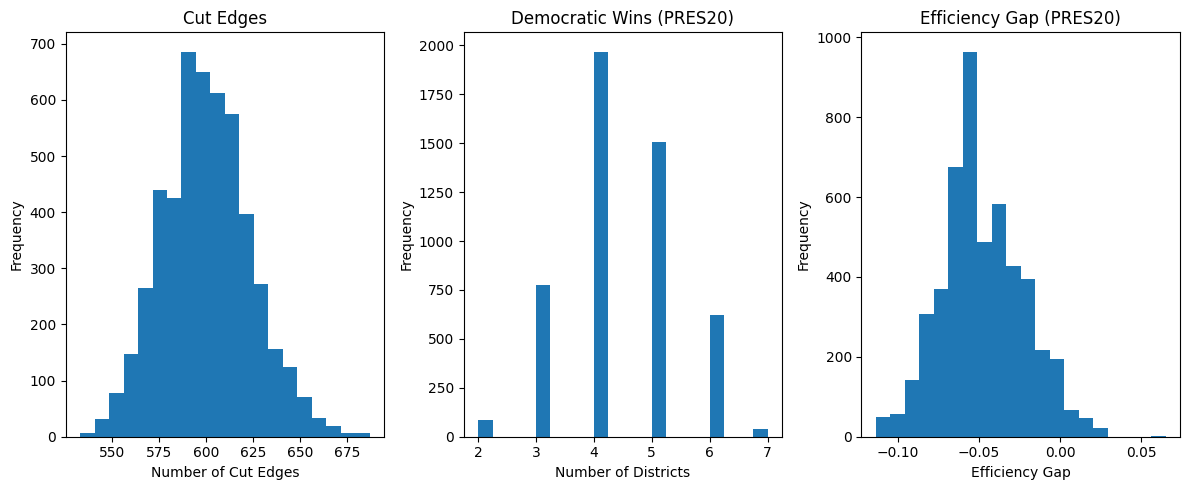

In [11]:
import pandas as pd
import time

total_steps_in_run = 5000

elections = [
    Election('PRES20', {'Democratic': 'G20PREDBID', 'Republican': 'G20PRERTRU'}),
    Election('GOV18',{'Democratic': 'G18GOVDJOR', 'Republican': 'G18GOVRLIT'}),
]

my_updaters = {
    'population': updaters.Tally('TOTPOP', alias='population'),
    'cut_edges': cut_edges,
    'VAP': updaters.Tally('VAP', alias='VAP'),
}

election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

initial_partition = Partition(
    id_graph,
    assignment='SDIST',
    updaters=my_updaters
)

ideal_population = sum(initial_partition['population'].values()) / len(initial_partition)

proposal = partial(recom,
                    pop_col='TOTPOP',
                    pop_target=ideal_population,
                    epsilon=0.5,
                    node_repeats=2
                )

compactness_bound = constraints.UpperBound(
    lambda p: len(p['cut_edges']),
    2 * len(initial_partition['cut_edges'])
)

pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.5)

chain = MarkovChain(
    proposal=proposal,
    constraints=[pop_constraint, compactness_bound],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=total_steps_in_run
)

cut_edges_data = []
dem_wins_data = []
eg_data = []
pres20_shares = []
gov18_shares = []

start_time = time.time()
for partition in chain.with_progress_bar():
    cut_edges_data.append(len(partition['cut_edges']))
    dem_wins_data.append(partition['PRES20'].wins('Democratic'))
    eg_data.append(partition['PRES20'].efficiency_gap())
    pres20_shares.append(partition['PRES20'].percents('Democratic'))
    gov18_shares.append(partition['GOV18'].percents('Democratic'))

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].hist(cut_edges_data, bins=20)
axes[0].set_title('Cut Edges')
axes[0].set_xlabel('Number of Cut Edges')
axes[0].set_ylabel('Frequency')

axes[1].hist(dem_wins_data, bins=20)
axes[1].set_title('Democratic Wins (PRES20)')
axes[1].set_xlabel('Number of Districts')
axes[1].set_ylabel('Frequency')

axes[2].hist(eg_data, bins=20)
axes[2].set_title('Efficiency Gap (PRES20)')
axes[2].set_xlabel('Efficiency Gap')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('id_histograms.png')
plt.show()

/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/pandas/plotting/_matplotlib/boxplot.py:112: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(ys, **kwds)
/opt/anaconda3/envs/gerry/lib/python3.13/site-packages/pandas/plotting/_matplotlib/boxplot.py:112: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(ys, **kwds)


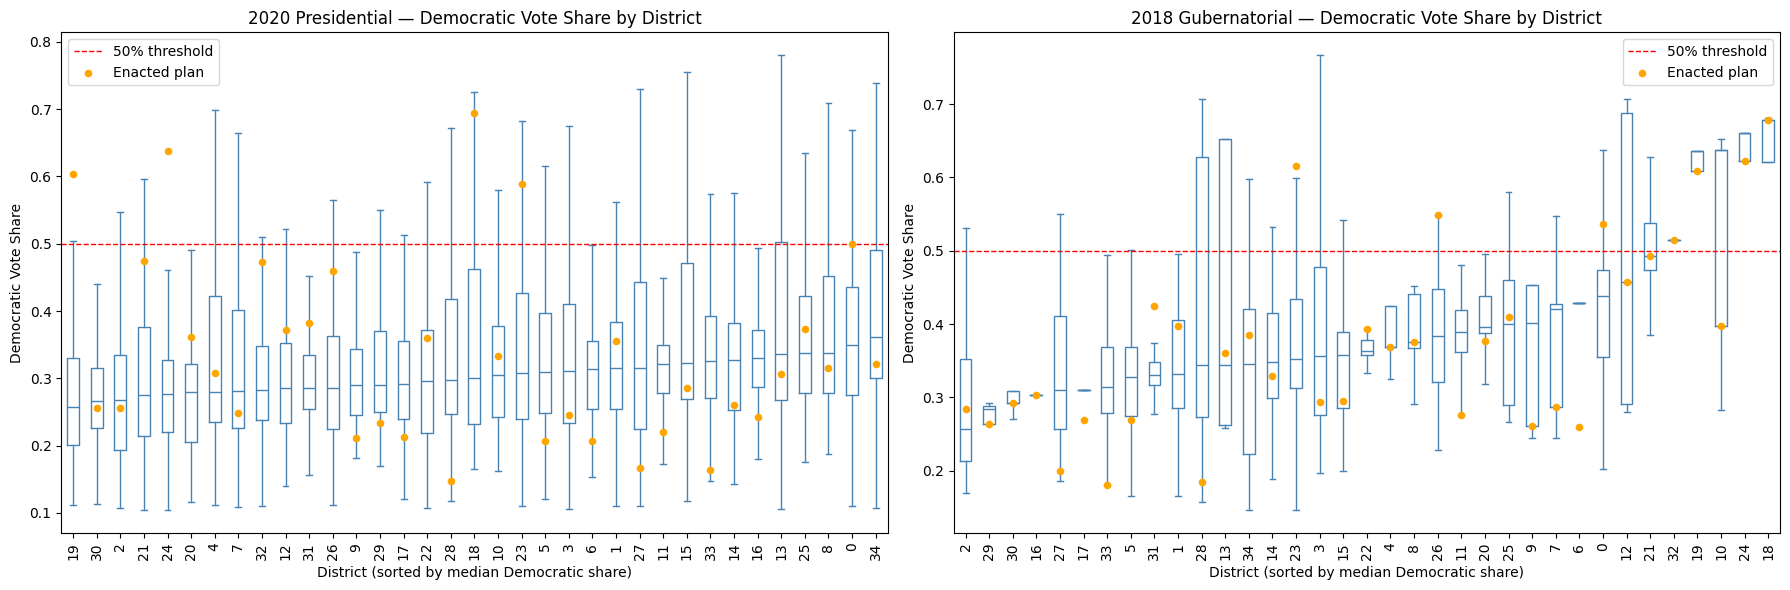

In [12]:
pres20_df = pd.DataFrame(pres20_shares)
gov18_df = pd.DataFrame(gov18_shares)

pres20_sorted = pres20_df[pres20_df.median().sort_values().index]
gov18_sorted = gov18_df[gov18_df.median().sort_values().index]

pres20_enacted = pres20_shares[0]
gov18_enacted = gov18_shares[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, enacted, title in [
    (axes[0], pres20_sorted, pres20_enacted, '2020 Presidential — Democratic Vote Share by District'),
    (axes[1], gov18_sorted, gov18_enacted, '2018 Gubernatorial — Democratic Vote Share by District'),
]:
    df.plot.box(ax=ax, vert=True, showfliers=False, color='steelblue')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
    enacted_vals = [enacted[d] for d in df.columns]
    ax.scatter(range(1, len(df.columns) + 1), enacted_vals,
               color='orange', zorder=5, s=20, label='Enacted plan')
    ax.set_title(title)
    ax.set_xlabel('District (sorted by median Democratic share)')
    ax.set_ylabel('Democratic Vote Share')
    ax.tick_params(axis='x', rotation=90)
    ax.legend()

plt.tight_layout()
plt.savefig('id_boxplots.png', dpi=150)
plt.show()

In [13]:
end_time = time.time()
print('The time of execution of above program is :',
      (end_time-start_time)/60, 'mins')

The time of execution of above program is : 0.19109326601028442 mins
